# Blink detection on RN30 — all four models

This notebook runs every published model on **one 45-frame window from RN30**
containing a single blink, and shows the whole path from stored data to a
frame-wise blink prediction.

| model | runtime | needs the 160-d feature stream |
|---|---|---|
| `densenet121-union` | ONNX | no |
| `blinklint-union` | ONNX | no |
| `blinklinmult-union` | ONNX | **yes** |
| `blinkcnn` | PyTorch | no |

The three `*-union` models are the published 1.x networks from the
[paper](https://www.mdpi.com/2313-433X/9/10/196), frozen as ONNX graphs.
`blinkcnn` is the current v2 frame-wise model.

**What the figure shows.** The models output a continuous *eye-closeness* signal
in `[0, 1]` per frame. A blink is a fast fall and a slower rise. Thresholding
that curve turns it into a frame-wise binary prediction — `0` open, `1` closed —
and this notebook compares a single cut against hysteresis.

**Requirements:** `uv sync --extra onnx --extra train --extra notebooks`, plus a
built `data/processed/rn30/rn30.h5`.

## 1. Load one window

RN30 is stored as 45-frame windows, one eye each: the eye crops the models
consume, the 160-d descriptors the two-stream model needs, and the per-frame
`eye_state` annotation used as ground truth.

In [1]:
import json
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

CORPUS = Path("../../data/processed/rn30/rn30.h5")
WINDOW = "test_22|001320|left"  # one clean blink, centred in the window

with h5py.File(CORPUS, "r") as handle:
    group = handle["test"][WINDOW]
    crops = np.asarray(group["eye_image"][:], dtype=np.float32)  # (45, 3, 64, 64)
    features = np.asarray(group["eye_feature"][:], dtype=np.float32)  # (45, 160)
    truth = np.asarray(group["eye_state"][:], dtype=np.float32)  # (45,)

closed = np.flatnonzero(truth > 0.5)
print(f"crops     {crops.shape}  range [{crops.min():.2f}, {crops.max():.2f}]")
print(f"features  {features.shape}")
print(f"annotated closed frames: {closed.tolist()}")

crops     (45, 3, 64, 64)  range [0.16, 0.76]
features  (45, 160)
annotated closed frames: [21, 22, 23]


Crops are already `[0, 1]` float32, channel-first. **Do not normalise them
yourself** — each model was trained on a different convention (the 1.x models on
ImageNet mean/std, `blinkcnn` on plain `/255`) and `BlinkDetector` applies the
right one from the model's own metadata. Passing pre-normalised crops silently
degrades accuracy without raising anything.

## 2. The eye crops

The blink is visible as the lid closing over the middle frames.

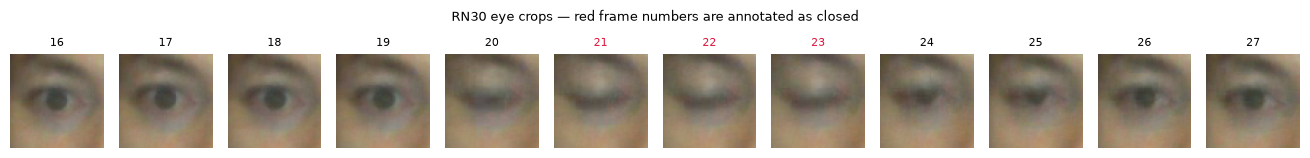

In [2]:
show = range(16, 28)
fig, axes = plt.subplots(1, len(show), figsize=(len(show) * 1.1, 1.6))
for ax, frame in zip(axes, show):
    ax.imshow(np.transpose(crops[frame], (1, 2, 0)))
    ax.set_title(f"{frame}", fontsize=8, color="crimson" if truth[frame] > 0.5 else "black")
    ax.axis("off")
fig.suptitle("RN30 eye crops — red frame numbers are annotated as closed", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Feature extraction (the 160-d stream)

`blinklinmult-union` reads a second input alongside the pixels: 160 handcrafted
descriptors per frame — 71 eye-region landmarks (142), 5 iris landmarks (10),
2 iris diameters, 2 eyelid–pupil distances, the eye-aspect ratio, and 3 head-pose
angles.

These come from **exordium** and are already stored in the corpus. To extract
them from raw video instead:

```python
# needs: uv sync --extra preprocess
from blinklinmult.preprocess.extractors import FrameDescriber

describer = FrameDescriber()
descriptor, valid = describer.describe(frame)   # (160,) plus a validity flag
```

Extraction is skipped here because the corpus already carries the vectors.

### Two conversions the 1.x model requires

The v2 schema stores these features differently from how 1.x consumed them:

1. **Block order.** 1.x put head pose *first*; v2 puts it last.
2. **Standardisation.** 1.x z-scored each descriptor against corpus-wide
   statistics. Fed raw values, the model's logits sit near −9.9 and it **never
   fires** — silently, with no error.

`prepare_features` does both. Measured on this window: raw v2 features give a
peak probability of **0.0002**; converted, **0.91**.

In [3]:
STATS = Path("../../artifacts/onnx/rn30_feature_stats.json")

stats = json.loads(STATS.read_text())
print(f"corpus statistics over {stats['frames']:,} annotated RN30 frames")

corpus statistics over 130,252 annotated RN30 frames


## 4. Load the models and score the window

Weights download from the Hub on first use and cache locally.

### Window length matters for the 1.x sequence models

`blinklint-union` and `blinklinmult-union` were trained on **15-frame windows**
(~0.5 s at 25 fps). Feeding them this corpus's 45-frame window costs a lot of
accuracy, so `score_long` slides the native window across the recording and
averages the overlapping predictions.

**Averaging, not taking the maximum.** A maximum can only push a frame's score
*up*, so one badly-positioned window — where the blink sits at the very edge, an
input the model never trained on — raises that frame permanently and errors
accumulate rather than cancelling. Measured over 200 RN30 windows carrying an
annotated blink:

| reduction | stride | precision | recall | F1 |
|---|---:|---:|---:|---:|
| maximum | 1 | 0.236 | 0.954 | 0.379 |
| **mean** | **1** | **0.346** | 0.899 | **0.500** |
| mean | 15 | 0.322 | 0.876 | 0.471 |

The maximum's near-perfect recall against 0.24 precision is the signature of
over-firing: it fires almost everywhere, so it never misses. Note this is why
*recall alone is a misleading metric here* — on recall the maximum looks best.

`score_long` handles all of it: frame-wise models are scored in one pass, and
sequence models get the sliding window they expect.

In [4]:
from blinklinmult import BlinkDetector

MODELS = ["densenet121-union", "blinklint-union", "blinklinmult-union", "blinkcnn"]

signals = {}
for model_id in MODELS:
    detector = BlinkDetector.from_pretrained(model_id)

    if detector.spec.needs_features:
        # Reordered and standardised for the 1.x layout; see section 3.
        stream = detector.prepare_features(features, stats["mean"], stats["std"])
    else:
        stream = None

    signals[model_id] = detector.score_long(crops, stream)
    peak = int(np.argmax(signals[model_id]))
    native = detector.spec.window or crops.shape[0]
    print(
        f"{model_id:22s} window {native:2d}  peak at frame {peak:2d}, "
        f"max {signals[model_id].max():.3f}"
    )

densenet121-union      window 45  peak at frame 22, max 1.000


blinklint-union        window 15  peak at frame 21, max 0.999


blinklinmult-union     window 15  peak at frame 22, max 0.843


blinkcnn               window 45  peak at frame 23, max 0.947


## 5. From a continuous signal to a frame-wise prediction

The curve is thresholded to get a binary per-frame label — `0` open, `1` closed.
Two ways to do it:

**Single threshold.** One cut. Simple, but it has to be low enough to catch the
shallow start of a closure and high enough to ignore noise, and no single value
does both well.

**Hysteresis.** Two cuts doing separate jobs: a run must *peak* above the **high**
threshold to count as a blink at all, but it *extends* while it stays above the
**low** one. That matches the physical shape of a blink — the signal ramps down
through closing, plateaus while closed, and ramps back up — so the low threshold
recovers the true onset and offset that a single cut clips away.

On `blinkcnn` this is worth 0.19 → 0.52 event F1, which is why its published
operating point is a hysteresis pair (`0.53` / `0.25 × 0.53 = 0.1325`).

In [5]:
from blinklinmult.train.events import to_intervals


def binarise(signal, high, low=None):
    """Frame-wise 0/1 prediction from a closeness signal."""
    mask = np.ones(signal.shape[0], dtype=bool)
    prediction = np.zeros(signal.shape[0], dtype=int)
    for start, end in to_intervals(signal, mask, high, low):
        prediction[start : end + 1] = 1
    return prediction


MODEL = "blinkcnn"
signal = signals[MODEL]
high, ratio = 0.53, 0.25  # blinkcnn's validation-fitted operating point
low = high * ratio

single = binarise(signal, high)
hyst = binarise(signal, high, low)

print(f"annotated closed : {np.flatnonzero(truth > 0.5).tolist()}")
print(f"single threshold : {np.flatnonzero(single).tolist()}")
print(f"hysteresis       : {np.flatnonzero(hyst).tolist()}")

annotated closed : [21, 22, 23]
single threshold : [21, 22, 23]
hysteresis       : [20, 21, 22, 23]


## 6. The figure

Top: the continuous signal with both thresholds. Bottom: the resulting
frame-wise predictions against the annotation.

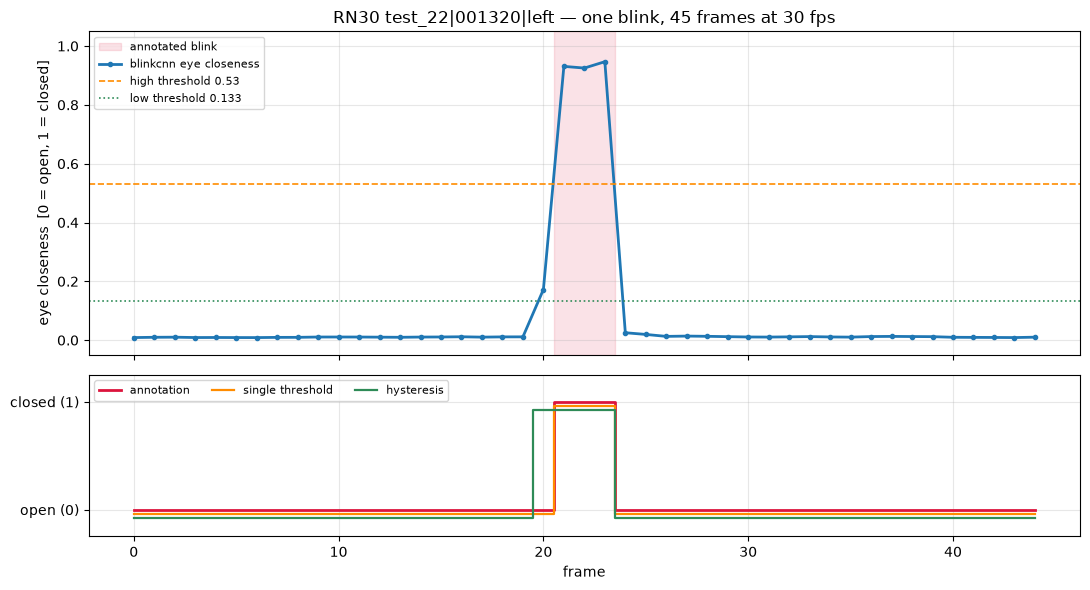

In [6]:
frames = np.arange(signal.shape[0])
fig, (top, bottom) = plt.subplots(
    2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1.5]}
)

top.axvspan(closed[0] - 0.5, closed[-1] + 0.5, color="crimson", alpha=0.12, label="annotated blink")
top.plot(
    frames,
    signal,
    color="#1f77b4",
    linewidth=2,
    marker="o",
    markersize=3,
    label=f"{MODEL} eye closeness",
)
top.axhline(high, color="darkorange", linestyle="--", linewidth=1.2, label=f"high threshold {high}")
top.axhline(low, color="seagreen", linestyle=":", linewidth=1.2, label=f"low threshold {low:.3f}")
top.set_ylabel("eye closeness  [0 = open, 1 = closed]")
top.set_ylim(-0.05, 1.05)
top.set_title(f"RN30 {WINDOW} — one blink, 45 frames at 30 fps")
top.legend(loc="upper left", fontsize=8)
top.grid(alpha=0.3)

bottom.step(frames, truth > 0.5, where="mid", color="crimson", linewidth=2, label="annotation")
bottom.step(
    frames, single - 0.04, where="mid", color="darkorange", linewidth=1.6, label="single threshold"
)
bottom.step(frames, hyst - 0.08, where="mid", color="seagreen", linewidth=1.6, label="hysteresis")
bottom.set_yticks([0, 1])
bottom.set_yticklabels(["open (0)", "closed (1)"])
bottom.set_xlabel("frame")
bottom.set_ylim(-0.25, 1.25)
bottom.legend(loc="upper left", fontsize=8, ncol=3)
bottom.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The three prediction traces are offset vertically so they do not overlap.
Hysteresis typically covers a frame or two more than the single cut at each edge
— that is the closing and opening ramp it recovers.

## 7. All four models on the same window

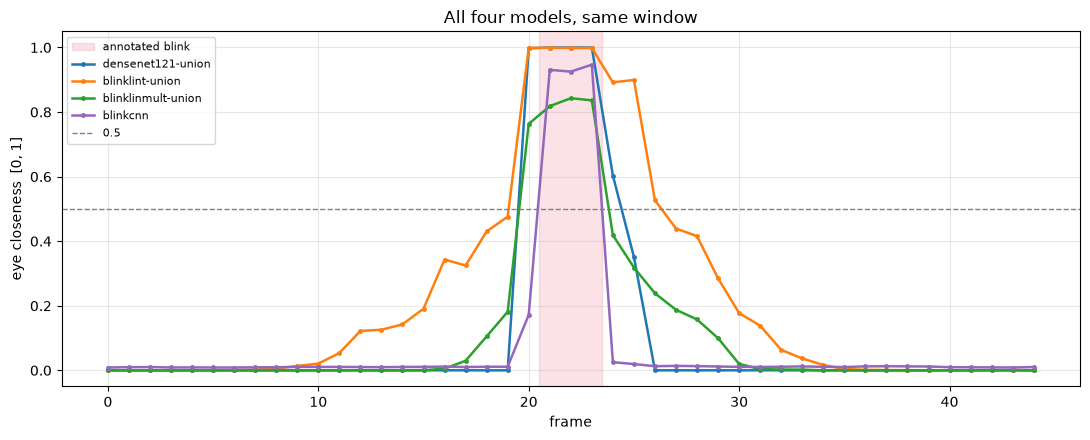

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axvspan(closed[0] - 0.5, closed[-1] + 0.5, color="crimson", alpha=0.12, label="annotated blink")
for model_id, colour in zip(MODELS, ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]):
    ax.plot(
        frames,
        signals[model_id],
        linewidth=1.8,
        color=colour,
        marker="o",
        markersize=2.5,
        label=model_id,
    )
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="0.5")
ax.set_xlabel("frame")
ax.set_ylabel("eye closeness  [0, 1]")
ax.set_ylim(-0.05, 1.05)
ax.set_title("All four models, same window")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Reading this plot.** All four should peak inside the shaded region. Differences
in *sharpness* are the interesting part: the frame-wise models
(`densenet121-union`, `blinkcnn`) judge each frame independently, so their curves
are spikier, while the sequence models (`blinklint-union`,
`blinklinmult-union`) see the whole window and produce smoother trajectories.

**One caveat on comparing these fairly.** Only `blinkcnn` has a
validation-fitted operating point. The 1.x models were released as weights with
no threshold, so they carry a plain `0.5` placeholder. Frame-level curves are
directly comparable; *event* counts are not, until their thresholds are fitted:

```python
from blinklinmult.fit import fit_operating_point

point = fit_operating_point(signals, annotations)   # on validation data
detector.calibrate(point)
```

## 8. Detecting blinks directly

`detect()` wraps signal → threshold → intervals in one call, using each model's
registered operating point.

In [8]:
detector = BlinkDetector.from_pretrained("blinkcnn")
intervals = detector.detect(crops)

print(f"annotated: [({closed[0]}, {closed[-1]})]")
print(f"detected : {intervals}")

annotated: [(21, 23)]
detected : [(20, 23)]
